In [1]:
import glob,os
import pandas as pd

In [2]:
Datapath = r"J:\BLA_three_types\csv_PFC_ways\cluster"
aba_dist = pd.read_csv(os.path.join(Datapath,"morphology_matrix_PFC_ways.csv"),sep = ",",index_col =0)

In [3]:
aba_dist

,251034_001_Vglut1_PFC_0.swc,251034_003_Vglut1_PFC_1.swc,251034_003_Vglut1_PFC_2.swc,251034_004_Vglut1_PFC_3.swc,251034_010_Vglut1_PFC_4.swc,251034_010_Vglut1_PFC_5.swc,251034_010_Vglut1_PFC_6.swc,251039_020_Vglut1_PFC_7.swc,251039_020_Vglut1_PFC_8.swc,251039_021_Vglut1_PFC_10.swc,251039_021_Vglut1_PFC_9.swc,251039_029_Vglut1_PFC_11.swc,251039_029_Vglut1_PFC_12.swc,251039_029_Vglut1_PFC_13.swc,251039_029_Vglut1_PFC_14.swc,251039_029_Vglut1_PFC_15.swc,251039_033_Vglut1_PFC_16.swc
251034_001_Vglut1_PFC_0.swc,0.000000,691.961343,755.647919,1037.739450,989.452010,1046.181536,750.894629,1064.104798,1077.793324,1567.897104,1564.563873,1533.741211,611.093347,663.845056,773.247772,709.619201,883.489478
251034_003_Vglut1_PFC_1.swc,691.961343,0.000000,1277.689177,1231.429292,1159.814831,1385.463643,1140.690827,1326.569986,1112.262358,1666.276342,1551.007027,1748.368325,637.502813,639.505223,1172.489197,912.959318,486.185948
251034_003_Vglut1_PFC_2.swc,755.647919,1277.689177,0.000000,970.639697,595.418832,501.532216,587.296802,645.314179,694.959366,1243.592860,1275.626738,1969.594002,818.616322,733.662032,398.379815,662.975094,1033.427163
251034_004_Vglut1_PFC_3.swc,1037.739450,1231.429292,970.639697,0.000000,861.293601,1033.066691,767.408213,1076.815853,1013.093086,1659.383846,1626.703440,1935.815464,849.506478,861.776319,889.395283,576.454426,1351.662444
251034_010_Vglut1_PFC_4.swc,989.452010,1159.814831,595.418832,861.293601,0.000000,249.763590,736.544626,712.016185,594.526560,1214.215612,1279.152584,2221.164434,822.835071,634.178249,623.639838,727.883821,1066.455531
251034_010_Vglut1_PFC_5.swc,1046.181536,1385.463643,501.532216,1033.066691,249.763590,0.000000,804.184279,700.543091,698.964820,1183.704287,1278.498383,2243.825779,949.006478,855.783478,559.917239,865.710693,1070.533473
251034_010_Vglut1_PFC_6.swc,750.894629,1140.690827,587.296802,767.408213,736.544626,804.184279,0.000000,790.852932,814.432705,1380.013139,1287.382746,1765.833338,809.325122,851.234652,643.258029,453.114004,1220.610287
251039_020_Vglut1_PFC_7.swc,1064.104798,1326.569986,645.314179,1076.815853,712.016185,700.543091,790.852932,0.000000,434.890876,1229.762076,1157.783882,1852.633449,973.350993,901.091661,615.055449,857.803230,1106.337707
251039_020_Vglut1_PFC_8.swc,1077.793324,1112.262358,694.959366,1013.093086,594.526560,698.964820,814.432705,434.890876,0.000000,1141.820514,1147.542262,1978.057760,882.504428,777.686453,673.082836,815.354887,972.332513
251039_021_Vglut1_PFC_10.swc,1567.897104,1666.276342,1243.592860,1659.383846,1214.215612,1183.704287,1380.013139,1229.762076,1141.820514,0.000000,250.081216,1879.626602,1485.126429,1407.995165,1281.263450,1419.738677,1432.342667


# 分析可视化

In [4]:
from scipy.spatial.distance import squareform,pdist
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette,fcluster
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
import seaborn as sns

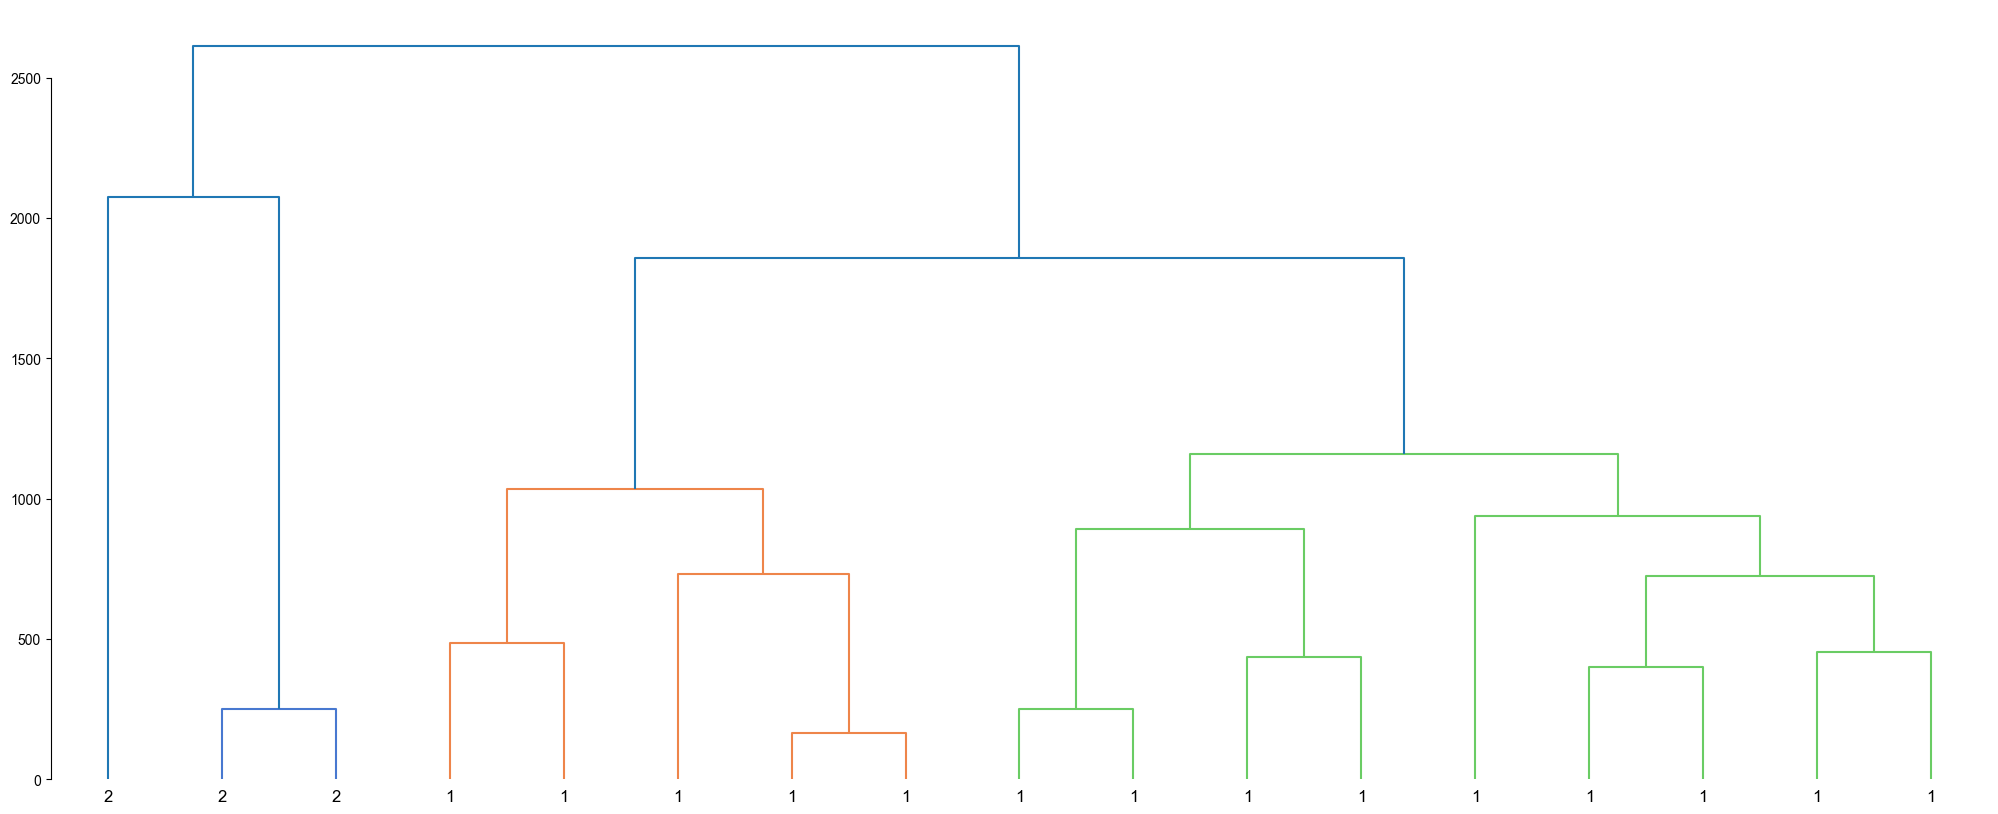

In [6]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rc("font",family="Arial")


set_link_color_palette([mcl.to_hex(c) for c in sns.color_palette('muted', 10)])
# To generate a linkage, we have to bring the matrix from square-form to vector-form
aba_vec = squareform(aba_dist, checks=False)
# Generate linkage
Z = linkage(aba_vec,method="ward")
# Plot a dendrogram
fig = plt.figure(figsize=(25, 10))
# dn = dendrogram(Z,truncate_mode='level',count_sort=True,distance_sort='descending')
c1 = fcluster(Z,t=2300,criterion = "distance")
dn = dendrogram(Z,truncate_mode='level',count_sort=True,labels=c1,distance_sort='descending')
ax = plt.gca()
# ax.set_xticklabels(ax.get_xticklabels(),)

# ax.set_yticklabels(ax.get_yticklabels(),fontproperties = font)
sns.despine(trim=True, bottom=True)
# # plt.savefig(r"E:\VMH\male part\all_cluster_MPO_male_a
# verage.jpg")
figpath = r"J:\BLA_three_types\csv_PFC_ways\cluster"
figname = "BLA_3_typesclassification_ward"

plt.savefig(os.path.join(figpath,figname + ".pdf"),dpi =600,format="pdf")
plt.savefig(os.path.join(figpath,figname + ".jpg"),dpi =600,format="jpg")

In [11]:
c1 = fcluster(Z,t=1500,criterion = "distance")

In [12]:

n_clusters = max(c1)
n_clusters

4

In [13]:
clusterPath = r"J:\BLA_three_types\csv_PFC_ways\cluster\BLA_3_pathway4.xlsx"
cluster_infor = []

for i,file in enumerate(aba_dist.columns.to_list()):
        neuron = {}
        # neuron["file"] = file
        neuron["cluster"] = c1[i]
        # for swc in filelist:
        #     if file == swc[0:10]:
        #         neuron["file"] = swc
        # # neuron["neurons"] = file[0:10]
        #         neuron["neurons"] = file[0:10]
        #         neuron["genotype"] = swc.split(".")[0].split("_")[-2]
        #         neuron["location"] = swc.split(".")[0].split("_")[-1]
        # # neuron["branches"] = item.n_branches
        # neuron["length"] = item.cable_length
        neuron["file"] = file
        cluster_infor.append(neuron)
#         del item,neuron
#         gc.collect()
dfc = pd.DataFrame(cluster_infor)
dfc2 = dfc.set_index("file")
dfc2.to_excel(clusterPath)

In [14]:
dfc2

,cluster
file,
251034_001_Vglut1_PFC_0.swc,1
251034_003_Vglut1_PFC_1.swc,1
251034_003_Vglut1_PFC_2.swc,2
251034_004_Vglut1_PFC_3.swc,2
251034_010_Vglut1_PFC_4.swc,2
251034_010_Vglut1_PFC_5.swc,2
251034_010_Vglut1_PFC_6.swc,2
251039_020_Vglut1_PFC_7.swc,2
251039_020_Vglut1_PFC_8.swc,2


In [11]:
# new version add the swc infor
filelist = os.listdir(r"F:\all_neurons_0616\HY_final")

In [20]:
clusterPath = r"F:\20250418_figs\2025_0418_NTS\PVH-NTS_cluster.xlsx"
cluster_infor = []
for i,file in enumerate(aba_dist.columns.to_list()):
        neuron = {}
        # neuron["file"] = file
        neuron["cluster"] = c1[i]
        for swc in filelist:
            if file == swc[0:10]:
                neuron["file"] = swc
        # neuron["neurons"] = file[0:10]
                neuron["neurons"] = file[0:10]
                neuron["genotype"] = swc.split(".")[0].split("_")[-2]
                neuron["location"] = swc.split(".")[0].split("_")[-1]
        # neuron["branches"] = item.n_branches
        # neuron["length"] = item.cable_length
        cluster_infor.append(neuron)
#         del item,neuron
#         gc.collect()
dfc = pd.DataFrame(cluster_infor)
dfc2 = dfc.set_index("file")
dfc2.to_excel(clusterPath)

In [22]:
dfc2

,cluster,neurons,genotype,location
file,,,,
195037_001_Oxt_PVH.swc,3,195037_001,Oxt,PVH
195037_023_Oxt_PVHd.swc,3,195037_023,Oxt,PVHd
195037_024_Oxt_PVH.swc,1,195037_024,Oxt,PVH
195037_032_Oxt_PVH.swc,4,195037_032,Oxt,PVH
195037_039_Oxt_PVHd.swc,3,195037_039,Oxt,PVHd
...,...,...,...,...
211597_011_Sst_PVH.swc,2,211597_011,Sst,PVH
212202_025_Trh_PVHd.swc,2,212202_025,Trh,PVHd
212202_026_Trh_PVHd.swc,1,212202_026,Trh,PVHd


In [23]:
dfc2.genotype.value_counts()

Oxt        41
Pdyn       35
Adcyap1    14
Trh         3
Penk        2
Tac2        2
Tac1        1
Sst         1
Crh         1
Name: genotype, dtype: int64

In [24]:
dfc2.location.value_counts()

PVHd    53
PVH     47
Name: location, dtype: int64

In [21]:
clusterPath = r"E:\20220210_for_figs\08 subplots\0827 hip\HIP_max_cluster.xlsx"
cluster_infor = []
for i,file in enumerate(aba_dist.columns.to_list()):
        neuron = {}
        neuron["file"] = file
        neuron["neuron"] = file[0:10]
        neuron["cluster"] = c1[i]
        # neuron["neurons"] = item.name[0:10]
        # neuron["genotype"] = a[2]
        # neuron["location"] = a[3]
        # neuron["branches"] = item.n_branches
        # neuron["length"] = item.cable_length
        cluster_infor.append(neuron)
#         del item,neuron
#         gc.collect()
dfc = pd.DataFrame(cluster_infor)
dfc2 = dfc.set_index("neuron")
dfc2.to_excel(clusterPath)

In [10]:

import pickle
DataPath = r"R:\python"
c1Path = os.path.join(DataPath,"c1_Gao_HY_all.pkl")
with open(c1Path,"wb") as f:
    pickle.dump(c1,f)


In [25]:
c1

array([ 5, 29,  9, ..., 21, 21, 21], dtype=int32)

In [27]:
aba_dist.columns.to_list()

['192710_002',
 '192710_003',
 '192710_004',
 '192710_005',
 '192710_007',
 '192710_008',
 '192710_009',
 '192710_010',
 '192710_012',
 '192710_013',
 '192710_014',
 '192710_016',
 '192710_017',
 '192710_018',
 '192710_019',
 '192710_020',
 '192710_021',
 '192710_026',
 '192710_029',
 '192710_032',
 '192710_035',
 '192710_043',
 '192710_045',
 '192710_046',
 '192710_047',
 '192710_048',
 '192710_050',
 '192710_054',
 '192710_057',
 '192710_058',
 '192710_059',
 '192710_060',
 '192710_061',
 '192710_062',
 '192710_063',
 '192710_064',
 '192710_066',
 '192710_067',
 '192711_001',
 '192711_002',
 '192711_003',
 '192711_004',
 '192711_005',
 '192711_006',
 '192711_007',
 '192711_008',
 '192711_009',
 '192711_010',
 '192711_011',
 '192711_012',
 '192711_013',
 '192711_014',
 '192711_015',
 '192711_016',
 '192711_017',
 '192711_018',
 '192711_020',
 '192711_021',
 '192712_001',
 '192712_003',
 '192712_004',
 '192712_007',
 '192712_008',
 '192712_009',
 '192712_012',
 '192712_013',
 '192712_0

In [25]:
clusterPath = r"E:\all neurons 0312\rawdata\Agrp\all_Agrp.xlsx"
cluster_infor = []
for i,file in enumerate(aba_dist.columns.to_list()):
        neuron = {}
        neuron["neuron"] = file
        neuron["cluster"] = c1[i]
        # neuron["neurons"] = item.name[0:10]
        # neuron["genotype"] = a[2]
        # neuron["location"] = a[3]
        # neuron["branches"] = item.n_branches
        # neuron["length"] = item.cable_length
        cluster_infor.append(neuron)
#         del item,neuron
#         gc.collect()
dfc = pd.DataFrame(cluster_infor)
dfc2 = dfc.set_index("neuron")
dfc2.to_excel(clusterPath)

In [40]:
# new file for full labels 20211214
dfneuron = pd.read_csv(r"E:\20220210_for_figs\0616 figs\new classfication\morpho_cluster_label_220613.csv",sep =",")

In [42]:
dftmp = dfneuron.set_index("neuron",inplace= False)

In [43]:
dfdata = pd.concat([dftmp,dfc2],axis = 1)

In [45]:
dfdata.to_csv(r"E:\20220210_for_figs\0616 figs\new classfication\morpho_cluster_label_new.csv")

In [ ]:
%reset

In [14]:
import sys
sys.path.append(r"D:\python\core")

from brain_area import BrainArea
print("half finished")
ba = BrainArea()
# soma_xyz = n.nodes[n.nodes["type"] == "root"][["x", "y", "z"]].values
vols = {}
vols["root"] = navis.Volume.from_file(ba.search_brain_area_obj("root")[-1])
vols["root"].color = "white"
# vols["MPN"] = navis.Volume.from_file(ba.search_brain_area_obj("MPN")[-1])
# vols["MPN"].color = "green"
# region_color = {"PMv": "c", "VTA": "gold", "PVT": "tomato", "PAG": "blue", "BST": "violet","MEA":"m"}
# for region in region_color:
#     vols[region] = navis.Volume.from_file(ba.search_brain_area_obj(region)[-1])
#     vols[region].color = region_color[region]
# region_color = { "MPO": "m","PAG": "blue"}
# for region in region_color:
#     vols[region] = navis.Volume.from_file(ba.search_brain_area_obj(region)[-1])
#     vols[region].color = region_color[region]

half finished


specified material (mtl1)  not loaded!


# add module export cluster file

In [ ]:
# new file for full labels 20211214

import pandas as pd
# import gc
clusterPath = r"E:\all neurons 0312\rawdata\fig\all_HY_cluster_0312.xls"
cluster_infor = []
for i in range(n_clusters):
    this = n[c1 ==(i+1)]
    for item in this:
        neuron = {}
        a = item.name.split("_")
        neuron["file"] = item.name
        neuron["cluster"] = i+1
        neuron["neurons"] = item.name[0:10]
        neuron["genotype"] = a[2]
        neuron["location"] = a[3]
        # neuron["branches"] = item.n_branches
        # neuron["length"] = item.cable_length
        cluster_infor.append(neuron)
#         del item,neuron
#         gc.collect()
dfc = pd.DataFrame(cluster_infor)
dfc2 = dfc.set_index("file")
dfc2.to_excel(clusterPath)



In [ ]:
# V2 for esr MPO neurons
import pandas as pd
# import gc
clusterPath = r"E:\Esr1_MPO_all\MPO_esr1_all_4.xls"
cluster_infor = []
for i in range(n_clusters):
    this = n[c1 ==(i+1)]
    for item in this:
        neuron = {}
        a = item.name.split("_")
        neuron["file"] = item.name
        neuron["cluster"] = i+1
        neuron["neurons"] = item.name[0:10]
        neuron["branches"] = item.n_branches
        neuron["length"] = item.cable_length
        mousename = item.name[0:5]
        if mousename in ["18708","18709","18710","18711"]:
            neuron["gender"] = "female"
        elif mousename in ["18712","18713","18714","18715"]:
            neuron["gender"] = "male"
        else:
            neuron["gender"] = "undefined"
        cluster_infor.append(neuron)
#         del item,neuron
#         gc.collect()
dfc = pd.DataFrame(cluster_infor)
dfc2 = dfc.set_index("file")
dfc2.to_excel(clusterPath)

In [ ]:
mousename = item.name[0:5]
print(type(mousename))

In [ ]:
import pandas as pd
import gc

clusterPath = r"E:\all neurons 1213\MPO_1213\MPO_male_all_4.xls"
clusters_id = {}
for i in range(n_clusters):
    this = n[c1 ==(i+1)]
    for item in this:
#         a = item.name
        clusters_id[item.name[0:6]+item.name[-3:]+".swc"] = i+1
df = pd.DataFrame.from_dict(clusters_id,orient='index',columns=['cluster'])
df.to_excel(clusterPath)

In [ ]:
# for zha xi 输出性别和cluster
import pandas as pd
clusterPath = r"E:\POMC\1st\POMC_3.xls"
clusters_id = {}
for i in range(n_clusters):
    this = n[c1 ==(i+1)]
#     print(this)
    for item in this:
#         a = item.name
        clusters_id[item.name[0:5]+item.name[-3:]+".swc"] = i+1
df = pd.DataFrame.from_dict(clusters_id,orient='index',columns=['cluster'])
df.loc[:,"gender"]= "female"
df.loc[:,"type"]= df.loc[:,"gender"]+"_"+df.loc[:,"cluster"].astype(str)
df.to_excel(clusterPath)

# single plot for each cluster

In [ ]:
from PIL import Image,ImageOps,ImageFont,ImageDraw
from collections import Counter
import re,os,math,gc

In [ ]:
def _crop_concate_images(front_file,top_file,left_file,soma_ba,terminal_sep):
    """
    crop and concatenate front,top and left view of img.
    save concatenated figs in the same directory
    Arguments:
        *_file: path of the files
    Return:
        No return.
    """
    print(front_file)
    name = re.findall("(\d+_.*)_front",front_file)[0]
    dirname = os.path.dirname(front_file)
    print(name)
    f1 = Image.open(front_file).rotate(-90)
    t1 = Image.open(top_file).rotate(90)
    l1 = Image.open(left_file)
    # f1 = f1.crop((250, 300, 2000, 2000))
    # t1 = t1.crop((200, 500, 2000, 1800))
#     l1 = l1.crop((300, 0, 2000, 2000))
#     os.remove(left_file)
#     l1.save(left_file)

    result = Image.new(f1.mode, (5000,2000))

    result.paste(f1, box=(0, 0))

    result.paste(l1, box=(1600, 0))

    result.paste(t1, box=(3200, 0))
    draw = ImageDraw.Draw(result)
    draw.text(xy=(200, 10), text="Soma:" + soma_ba, font=font, fill=(255, 0, 0))
#     draw.text(xy=(200, 80), text="Soma_manual:" + soma_manual, font=font, fill=(255, 0, 0))
    draw.text(xy=(200, 80), text="Terminal:" + terminal_sep, font=font, fill=(0, 0, 255))

    if "PAG" in terminal_fps:
        filename = os.path.join(dirname, name + "_PAG.png")
    else:
        filename = os.path.join(dirname, name + ".png")

    result.save(filename)
    result.close()
    del result
#     os.remove(front_file)
#     os.remove(top_file)

#     f1.save(front_file)
#     t1.save(top_file)





pklPath = r"E:\all neurons 1213\all_pkl_files"
savedir = r"E:\all neurons 1213\PVH_1222\fig"
TTFPath = r"D:\font\song.TTF"
font = ImageFont.truetype(TTFPath, size=60)
for i in range(n_clusters):
#     ax = axes[i]
#     ax.set_title(f"cluster{i+1}")
    this = n[c1 ==(i+1)]
    
    folder = "cluster_%d"%(i+1)
    foldernew = os.path.join(savedir,folder)
    os.mkdir(foldernew)
    fig, ax = navis.plot2d([this,*vols.values()],method="3d",palette = "Paired_r" ,scatter_kws={
        "color": "black",
        "s": 15
    })
    for dist, zim, ele, name in [(5, 90, 90, "left"), (5, 90, 0, "top"), (5, 0, 0, "front")]:
        ax.dist = dist
        ax.azim = zim
        ax.elev = ele
        filename = "cluster_%d_%s.png"%(i+1,name)
        filepath = os.path.join(foldernew, filename)
        plt.savefig(filepath, dpi=300)
        print("%s saved." % filename)
    plt.close("all")    
    for neuron in this:
        soma = neuron.nodes[neuron.nodes["type"] == "root"][["x", "y", "z"]].values
        fig, ax = navis.plot2d([neuron,soma,*vols.values()],method="3d",color = "red" ,scatter_kws={
            "color": "black",
            "s": 10
        })

        
        
        for dist, zim, ele, name in [(5, 90, 90, "left"), (5, 90, 0, "top"), (5, 0, 0, "front")]:
            ax.dist = dist
            ax.azim = zim
            ax.elev = ele
            filename = neuron.name + "cluster_%d_%s.png"%(i+1,name)
            filepath = os.path.join(foldernew,filename)
            plt.savefig(filepath, dpi=300)
            print("%s saved." % filename)
            
        
        pklfile = os.path.join(pklPath,neuron.name+".pkl")
        try:
            with open(pklfile,"rb") as f:
                infor = pickle.load(f)

            soma_ba = infor["somalocation"][0]
#             soma_manual = infor["soma_manual"]
            terminal_fps = dict(Counter(infor["terminallocations"]))
            terminal_str = str(sorted(terminal_fps.items(), key=lambda item:item[1], reverse=True))
            terminal_sep = ""
            total_lines = math.ceil(len(terminal_str)/100)
            for j in range(total_lines):
                if j < total_lines:
                    terminal_sep += terminal_str[j*100:(j+1 )* 100]
                    terminal_sep += "\n"
                elif j == total_lines-1:
                    terminal_sep += terminal_str[j*100:len(terminal_str)]
            # crop and concatenate pngs
            front_file = os.path.join(foldernew, neuron.name + "cluster_%d_front.png"%(i+1))
            top_file = os.path.join(foldernew, neuron.name + "cluster_%d_top.png"%(i+1))
            left_file = os.path.join(foldernew, neuron.name + "cluster_%d_left.png"%(i+1))
            _crop_concate_images(front_file,top_file,left_file,soma_ba,terminal_sep)
        except Exception as e:
            print(e)
        try:
            plt.close('all')
            plt.clf() 
            del front_file,top_file,left_file
            gc.collect()
        except Exception as e:
            print(e)

gc.collect()
    

In [ ]:
#add sites
def _crop_concate_images(front_file, top_file, left_file,site_file ,soma_ba,soma_manual,terminal_sep):
    """
    crop and concatenate front,top and left view of img.
    save concatenated figs in the same directory
    Arguments:
        *_file: path of the files
    Return:
        No return.
    """


    name = re.findall("(\d+_.*)_front", front_file)[0]
    dirname = os.path.dirname(front_file)

    f1 = Image.open(front_file).rotate(-90)
    t1 = Image.open(top_file).rotate(90)
    l1 = Image.open(left_file)
    s1 = Image.open(site_file)
    # f1 = f1.crop((250, 300, 2000, 2000))
    # t1 = t1.crop((200, 500, 2000, 1800))
#     l1 = l1.crop((300, 0, 2000, 2000))
#     os.remove(left_file)
#     l1.save(left_file)

    result = Image.new(f1.mode, (5200,2000))
    result.paste(s1, box=(50,800 ))

    result.paste(f1, box=(1000, 0))

    result.paste(l1, box=(2400, 0))

    result.paste(t1, box=(3800, 0))
    draw = ImageDraw.Draw(result)
    draw.text(xy=(200, 10), text="Soma:" + soma_ba, font=font, fill=(255, 0, 0))
    draw.text(xy=(200, 80), text="Soma_manual:" + soma_manual, font=font, fill=(255, 0, 0))
    draw.text(xy=(200, 150), text="Terminal:" + terminal_sep, font=font, fill=(0, 0, 255))

    if "PAG" in terminal_fps:
        filename = os.path.join(dirname, name + "_PAG.png")
    else:
        filename = os.path.join(dirname, name + ".png")

    result.save(filename)
    result.close()
    del result
#     os.remove(front_file)
#     os.remove(top_file)

#     f1.save(front_file)
#     t1.save(top_file)





pklPath = r"E:\esr_MPO_new\pkl_files"
savedir = r"E:\esr_MPO_new\plot"
TTFPath = r"D:\font\song.TTF"
sites = r"E:\for soma\neuron_male"
font = ImageFont.truetype(TTFPath, size=60)
for i in range(n_clusters):
#     ax = axes[i]
#     ax.set_title(f"cluster{i+1}")
    this = n[c1 ==(i+1)]
    folder = "cluster_%d"%(i+1)
    foldernew = os.path.join(savedir,folder)
    os.mkdir(foldernew)
    fig, ax = navis.plot2d([this,*vols.values()],method="3d",palette = "Paired_r" ,scatter_kws={
        "color": "black",
        "s": 15
    })
    for dist, zim, ele, name in [(5, 90, 90, "left"), (5, 90, 0, "top"), (5, 0, 0, "front")]:
        ax.dist = dist
        ax.azim = zim
        ax.elev = ele
        filename = "cluster_%d_%s.png"%(i+1,name)
        filepath = os.path.join(foldernew, filename)
        plt.savefig(filepath, dpi=300)
        print("%s saved." % filename)
    plt.close("all")    
    for neuron in this:
        fig, ax = navis.plot2d([neuron,*vols.values()],method="3d",color = "black" ,scatter_kws={
            "color": "black",
            "s": 15
        })

        
        
        for dist, zim, ele, name in [(5, 90, 90, "left"), (5, 90, 0, "top"), (5, 0, 0, "front")]:
            ax.dist = dist
            ax.azim = zim
            ax.elev = ele
            filename = neuron.name + "cluster_%d_%s.png"%(i+1,name)
            filepath = os.path.join(foldernew,filename)
            plt.savefig(filepath, dpi=300)
            print("%s saved." % filename)
            
        
        pklfile = os.path.join(pklPath,neuron.name+".pkl")
        try:
            with open(pklfile,"rb") as f:
                infor = pickle.load(f)

            soma_ba = infor["somalocation"][0]
            soma_manual = infor["soma_manual"]
            terminal_fps = dict(Counter(infor["terminallocations"]))
            terminal_str = str(sorted(terminal_fps.items(), key=lambda item:item[1], reverse=True))
            terminal_sep = ""
            total_lines = math.ceil(len(terminal_str)/100)
            for j in range(total_lines):
                if j < total_lines:
                    terminal_sep += terminal_str[j*100:(j+1 )* 100]
                    terminal_sep += "\n"
                elif j == total_lines-1:
                    terminal_sep += terminal_str[j*100:len(terminal_str)]
            # crop and concatenate pngs
            front_file = os.path.join(foldernew, neuron.name + "cluster_%d_front.png"%(i+1))
            top_file = os.path.join(foldernew, neuron.name + "cluster_%d_top.png"%(i+1))
            left_file = os.path.join(foldernew, neuron.name + "cluster_%d_left.png"%(i+1))
            site_file = os.path.join(sites,neuron.name[0:5]+neuron.name[0:5]+"-"+neuron.name[-3:]+".jpg")
            _crop_concate_images(front_file,top_file,left_file,site_file ,soma_ba,soma_manual,terminal_sep)
        except Exception as e:
            print(e)
        try:
            plt.close('all')
            plt.clf() 
            del front_file,top_file,left_file
            gc.collect()
        except Exception as e:
            print(e)

gc.collect()
    

In [15]:
# only for all/ no soma

from PIL import Image,ImageOps,ImageFont,ImageDraw
TTFPath = r"D:\font\song.TTF"
font = ImageFont.truetype(TTFPath, size=60)
savedir = r"E:\all neurons 0312\rawdata\fig\nor"
for i in range(0,5):
    
#     ax = axes[i]
#     ax.set_title(f"cluster{i+1}")
    this = n[c1 ==(i+1)]
    # soma = this.nodes.loc[this.nodes.type == "root"].loc[:,["x","y","z"]]
#     fig, ax = navis.plot2d([this,*vols.values()],method="3d",color = "Paired_r" ,scatter_kws={
#         "color": "black",
#         "s": 15
#     })
    fig, ax = navis.plot2d([this,*vols.values()],method="3d",color = "Paired_r",alpha = 0.5
    )
    
    for dist, zim, ele, name,rotate_x in [(5, 90, 90, "left",0), (5, 90, 0, "top",0), (5, 0, 0, "front",-90)]:
        ax.dist = dist
        ax.azim = zim
        ax.elev = ele
        
        filename = "Cluster_%d_%s.png"%(i+1,name)
        filename2 = "Cluster_%d"%(i+1)
        filepath = os.path.join(savedir, filename)
        plt.savefig(filepath, dpi=300)
        # name = re.findall("(\d+_.*)_front", front_file)[0]
        # dirname = os.path.dirname(front_file)
        image_file = Image.open(filepath).rotate(rotate_x)
        draw = ImageDraw.Draw(image_file)
        draw.text(xy=(300, 300), text=filename2, font=font, fill=(255, 0, 0))
        os.remove(filepath)
        image_file.save(filepath)
        image_file.close()
        
        print("%s saved." % filename)
    plt.close("all")

Plot neurons:   0%|          | 0/493 [00:00<?, ?it/s]

In [ ]:


# only for all

from PIL import Image,ImageOps,ImageFont,ImageDraw
TTFPath = r"D:\font\song.TTF"
font = ImageFont.truetype(TTFPath, size=60)
savedir = r"E:\all neurons 0312\rawdata\fig"
for i in range(n_clusters):
    
#     ax = axes[i]
#     ax.set_title(f"cluster{i+1}")
    this = n[c1 ==(i+1)]
    soma = this.nodes.loc[this.nodes.type == "root"].loc[:,["x","y","z"]]
#     fig, ax = navis.plot2d([this,*vols.values()],method="3d",color = "Paired_r" ,scatter_kws={
#         "color": "black",
#         "s": 15
#     })
    fig, ax = navis.plot2d([this,soma,*vols.values()],method="3d",color = "Paired_r",alpha = 0.5 ,scatter_kws={
        "color": "black",
        "s": 5
    })
    
    for dist, zim, ele, name,rotate_x in [(5, 90, 90, "left",0), (5, 90, 0, "top",0), (5, 0, 0, "front",-90)]:
        ax.dist = dist
        ax.azim = zim
        ax.elev = ele
        
        filename = "Cluster_%d_%s.png"%(i+1,name)
        filename2 = "Cluster_%d"%(i+1)
        filepath = os.path.join(savedir, filename)
        plt.savefig(filepath, dpi=300)
        # name = re.findall("(\d+_.*)_front", front_file)[0]
        # dirname = os.path.dirname(front_file)
        image_file = Image.open(filepath).rotate(rotate_x)
        draw = ImageDraw.Draw(image_file)
        draw.text(xy=(300, 300), text=filename2, font=font, fill=(255, 0, 0))
        os.remove(filepath)
        image_file.save(filepath)
        image_file.close()
        
        print("%s saved." % filename)
    plt.close("all")

In [ ]:
# only for  no vol
savedir = r"E:\all neurons 1213\HY test\fig"
for i in n2:
    
    fig, ax = navis.plot2d([i,soma[0]],method="3d",palette = "Paired_r" ,scatter_kws={
        "color": "r",
        "s": 15
    })
    for dist, zim, ele, name in [(5, 90, 90, "left"), (5, 90, 0, "top"), (5, 0, 0, "front")]:
        ax.dist = dist
        ax.azim = zim
        ax.elev = ele
        filename = "%s_%s.png"%(name,i.name)
        filepath = os.path.join(savedir, filename)
        plt.savefig(filepath, dpi=300)
        print("%s saved." % filename)
    plt.close("all")

In [ ]:
savedir = r"E:\all neurons 1213\HY test\fig"

    
fig, ax = navis.plot2d([n2,[soma_xyz,*vols.values()],method="3d",palette = "Paired_r" ,scatter_kws={
    "color": "black",
    "s": 20
})
for dist, zim, ele, name in [(5, 90, 90, "left"), (5, 90, 0, "top"), (5, 0, 0, "front")]:
    ax.dist = dist
    ax.azim = zim
    ax.elev = ele
    filename = "%s_%s.png"%(i.name,name)
    filepath = os.path.join(savedir, filename)
    plt.savefig(filepath, dpi=300)
    print("%s saved." % filename)
plt.close("all")

In [ ]:
import copy

In [ ]:
% 

In [ ]:
soma_xyz.shape

In [ ]:
fig, ax = navis.plot2d(n[0],method="3d_complex",palette = "Paired_r",alpha=1,scatter_kws={
    "color": "black",
    "s": 300
})
plt.show()
# for i in range(0, 360, 10):
#    # Change rotation
#    ax.azim = i
#    # Save each incremental rotation as frame
#    plt.savefig(r"E:\all neurons 1213\HY test\fig\frame_{0}.png".format(i), dpi=300)

In [ ]:
n[0].nodes

In [ ]:
soma = []
for i in n2:
    tmp = i.nodes.loc[i.nodes["type"] == "root"][["x", "y", "z"]].values
    soma.append(tmp)
    

In [ ]:
import json
datapath = r"E:\all neurons 0102\json\192710_009_pomc-cre_PMv.json"

In [ ]:

with open(datapath, 'r') as rf:
    data = json.load(rf)

In [ ]:
data

In [ ]:
data["terminalregion"]

In [ ]:
# 第三种方法讲key和value分装成元祖，在进行排序
f = zip(d.keys(), d.values())
c = sorted(f)
print(c)

In [ ]:
datatmp = zip(data["terminalregion"].keys(),data["terminalregion"].values())
datatmp2 = sorted(datatmp)
datatmp2

In [ ]:
data["terminalregion"].values()

In [ ]:
aa = data["terminalregion"]

In [ ]:
d = {'a': 1, 'b': 4, 'c': 2, 'f' : 12}
 
# 第一种方法，key使用lambda匿名函数取value进行排序
a = sorted(d.items(), key=lambda x: x[1])
a1 = sorted(d.items(),key = lambda x:x[1],reverse = True)
print(a)
print(a1)

In [ ]:
d.items()

In [ ]:
x = {'a':1,'b':2}


In [ ]:
x

In [ ]:
aa

In [ ]:
zeros = filter(lambda x:1 == x[1],aa.items())

In [ ]:
for (key,values) in zeros:
    print(key)
    print(values)

In [ ]:
aa.pop("PMv")

In [ ]:
try:
    aa.pop("ee")
    aa.pop("PMv")
    aa.pop("ff")
    aa.pop("ARH")
except Exception as e:
    print(e)


In [ ]:
for excludes in ["PB","root","ARH"]:
    try:
        aa.pop(excludes)
    except Exception as e:
        print(e)

In [ ]:
aa